In [ ]:
!pip install vllm openai gymnasium minigrid imageio

In [ ]:
import subprocess
import time

model_name = "Qwen/Qwen2.5-7B-Instruct"

print(f"Loading vLLM server with model: {model_name}")
print("Startup takes about 3–4 minutes...")

command = f"nohup python -m vllm.entrypoints.openai.api_server \
--model {model_name} \
--dtype auto \
--api-key empty \
--port 8000 \
--gpu-memory-utilization 0.9 \
> vllm_server.log 2>&1 &"

subprocess.run(command, shell=True)

Loading vLLM server with model: Qwen/Qwen2.5-7B-Instruct
Startup takes about 3–4 minutes...


CompletedProcess(args='nohup python -m vllm.entrypoints.openai.api_server --model Qwen/Qwen2.5-7B-Instruct --dtype auto --api-key empty --port 8000 --gpu-memory-utilization 0.9 > vllm_server.log 2>&1 &', returncode=0)

In [ ]:
import requests
import time

url = "http://localhost:8000/v1/models"
headers = {"Authorization": "Bearer empty"}

for i in range(20):
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            print("✅ vLLM loaded successfully")
            print("Model:", response.json()['data'][0]['id'])
            break
    except requests.exceptions.ConnectionError:
        print(f"[{i+1}/20] Server not ready, retrying...")
        time.sleep(10)
else:
    print("❌ Server failed to start. Check vllm_server.log")

[1/20] Server not ready, retrying...
[2/20] Server not ready, retrying...
[3/20] Server not ready, retrying...
[4/20] Server not ready, retrying...
[5/20] Server not ready, retrying...
[6/20] Server not ready, retrying...
[7/20] Server not ready, retrying...
✅ vLLM loaded successfully
Model: Qwen/Qwen2.5-7B-Instruct


My Text Wrapper

In [ ]:
import gymnasium as gym
from minigrid.wrappers import FullyObsWrapper
from minigrid.core.actions import Actions

class MinigridTextWrapper:

    def __init__(self, env_id, render_mode=None):

        self.env = gym.make(env_id, render_mode=render_mode)
        self.env = FullyObsWrapper(self.env)

        self.action_map = {
            "turn_left": Actions.left,
            "turn_right": Actions.right,
            "move_forward": Actions.forward
        }

    def _base(self):
        return self.env.unwrapped

    def _scan_objects(self):

        base = self._base()
        grid = base.grid

        objs = []

        for x in range(grid.width):
            for y in range(grid.height):

                cell = grid.get(x,y)

                if cell is None:
                    continue

                t = getattr(cell,"type",None)

                if t in ("lava","goal","wall"):
                    objs.append(f"{t} at [{y},{x}]")

        return objs

    def get_text_obs(self, obs):

        base = self._base()

        ax, ay = int(base.agent_pos[0]), int(base.agent_pos[1])
        agent_dir = int(base.agent_dir)

        dirs = ["right", "down", "left", "up"]
        facing = dirs[agent_dir]

        desc = f"Grid uses [row,column] coordinates. Agent at [{ay},{ax}] facing {facing}. "

        # ---------- FRONT CELL ----------
        front_obj = None
        if hasattr(base, "front_pos"):
            fx, fy = int(base.front_pos[0]), int(base.front_pos[1])
            front_obj = base.grid.get(fx, fy)

        if front_obj is None:
            desc += f"The cell directly in front of you at [{fy},{fx}] is empty. "
        else:
            desc += f"The cell directly in front of you at [{fy},{fx}] contains {front_obj.type}. "

        # ---------- OBJECT SCAN ----------
        objects = self._scan_objects()

        if objects:
            desc += "Objects: " + ", ".join(objects) + "."

        return desc

    def reset(self):

        obs,_ = self.env.reset()
        return self.get_text_obs(obs)

    def step(self, action_str):

        action = self.action_map.get(action_str.lower(),Actions.forward)

        obs,reward,terminated,truncated,info = self.env.step(action)

        done = terminated or truncated

        return self.get_text_obs(obs),reward,done,info

Calvin's Text Wrapper

In [ ]:
import gymnasium as gym
from minigrid.wrappers import FullyObsWrapper
from minigrid.core.actions import Actions
from minigrid.core.constants import IDX_TO_OBJECT, IDX_TO_COLOR


class MinigridTextWrapper:

    def __init__(self, env_id, render_mode=None):

        self.env = gym.make(env_id, render_mode=render_mode)
        self.env = FullyObsWrapper(self.env)

        self.action_map = {
            "turn_left": Actions.left,
            "turn_right": Actions.right,
            "move_forward": Actions.forward
        }

        self.recent_actions = []
        self.step_count = 0
        self.max_steps = 100

    def _get_text_observation(self, obs):

        grid = obs['image']
        descriptions = []

        # Step counter
        descriptions.append(f"- Step {self.step_count} of {self.max_steps}.")

        # Recent actions
        if self.recent_actions:
            descriptions.append(
                f"- Your last actions: {', '.join(self.recent_actions[-5:])}."
            )

        # ----- FRONT CELL -----
        front_obj_idx = grid[3, 5, 0]
        front_obj_name = IDX_TO_OBJECT[front_obj_idx]

        if front_obj_name in ['empty', 'unseen']:
            descriptions.append("- The space directly in front of you is clear.")
        elif front_obj_name == 'wall':
            descriptions.append("- You are right in front of a wall.")
        elif front_obj_name == 'lava':
            descriptions.append("- Directly in front of you is lava.")
        elif front_obj_name == 'goal':
            descriptions.append("- The GREEN GOAL is directly in front of you!")
        else:
            front_color = IDX_TO_COLOR[grid[3, 5, 1]]
            descriptions.append(
                f"- Directly in front of you is a {front_color} {front_obj_name}."
            )

        # ----- SCAN FOR OBJECTS -----
        h, w, _ = grid.shape

        goal_found = False

        for y in range(h):
            for x in range(w):

                if x == w//2 and y == h-1:
                    continue

                obj_idx = grid[x, y, 0]
                obj_name = IDX_TO_OBJECT[obj_idx]

                if obj_name in ['goal', 'lava']:

                    forward_steps = (h - 1) - y
                    side_steps = x - (w // 2)

                    pos_str = []

                    if forward_steps > 0:
                        pos_str.append(f"{forward_steps} steps forward")

                    if side_steps < 0:
                        pos_str.append(f"{abs(side_steps)} steps to your left")
                    elif side_steps > 0:
                        pos_str.append(f"{side_steps} steps to your right")

                    relative_position = " and ".join(pos_str)

                    if obj_name == "lava":
                        descriptions.append(f"- LAVA at {relative_position}.")
                    else:
                        descriptions.append(
                            f"- You see the GREEN GOAL located {relative_position}."
                        )
                        goal_found = True
        if not goal_found:
            descriptions.append(
                "- The goal is not in your field of view. You need to explore."
            )

        return "\n".join(descriptions)

    def reset(self):

        obs, _ = self.env.reset()

        self.recent_actions = []
        self.step_count = 0

        return self._get_text_observation(obs)

    def step(self, action_str):

        action = self.action_map.get(action_str.lower(), Actions.forward)

        obs, reward, terminated, truncated, info = self.env.step(action)

        done = terminated or truncated

        self.recent_actions.append(action_str)
        self.step_count += 1

        return self._get_text_observation(obs), reward, done, info

Bhargav's text Wrapper

In [ ]:
import gymnasium as gym
from minigrid.wrappers import FullyObsWrapper
from minigrid.core.actions import Actions


class MinigridTextWrapper:

    def __init__(self, env_id, render_mode=None):
        self.env = gym.make(env_id, render_mode=render_mode)
        self.env = FullyObsWrapper(self.env)
        self.action_map = {
            "turn_left": Actions.left,
            "turn_right": Actions.right,
            "move_forward": Actions.forward,
        }

    def _base(self):
        return self.env.unwrapped

    def get_text_obs(self, obs):
        base = self._base()
        ax, ay = int(base.agent_pos[0]), int(base.agent_pos[1])
        agent_dir = int(base.agent_dir)
        dirs = ["right", "down", "left", "up"]
        facing = dirs[agent_dir]
        desc = f"Agent at [{ax},{ay}] facing {facing}. "

        front_obj = None
        if hasattr(base, "front_pos"):
            fx, fy = int(base.front_pos[0]), int(base.front_pos[1])
            front_obj = base.grid.get(fx, fy)

        if front_obj is None:
            desc += "The cell directly in front of you is empty. "
        else:
            desc += f"The cell directly in front of you contains {front_obj.type}. "

        grid = base.grid
        objects = []
        for x in range(grid.width):
            for y in range(grid.height):
                cell = grid.get(x, y)
                if cell is None:
                    continue
                obj_type = getattr(cell, "type", None)
                if obj_type in ("lava", "goal", "wall"):
                    objects.append(f"{obj_type} at [{x},{y}]")
        if objects:
            desc += "Objects: " + ", ".join(objects) + "."
        return desc

    def reset(self):
        obs, _ = self.env.reset()
        return self.get_text_obs(obs)

    def step(self, action_str):
        action = self.action_map.get(action_str.lower(), Actions.forward)
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return self.get_text_obs(obs), reward, done, info

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [ ]:
import imageio
import os

def evaluate_agent(agent,
                   env_name="MiniGrid-LavaGapS6-v0",
                   num_episodes=10,
                   max_steps_per_episode=100,
                   gif_folder="episode_gifs"):

    print(f"Evaluating {env_name} for {num_episodes} episodes")

    env = MinigridTextWrapper(env_name, render_mode="rgb_array")

    os.makedirs(gif_folder, exist_ok=True)

    metrics = {
        "success_count": 0,
        "total_steps_success": 0,
        "total_inference_time": 0,
        "total_tokens": 0,
        "total_actions": 0
    }

    for episode in range(num_episodes):

        obs = env.reset()
        agent.reset()

        done = False
        step_count = 0
        episode_reward = 0

        frames = []

        # record initial frame
        frames.append(env.env.render())

        while not done and step_count < max_steps_per_episode:

            action, response, inf_time = agent.act(obs)

            metrics["total_inference_time"] += inf_time
            metrics["total_actions"] += 1

            obs, reward, done, _ = env.step(action)

            step_count += 1
            episode_reward += reward

            # record frame
            frames.append(env.env.render())

        success = episode_reward > 0

        if success:
            metrics["success_count"] += 1
            metrics["total_steps_success"] += step_count

        # save GIF
        gif_path = f"{gif_folder}/episode_{episode+1}.gif"
        imageio.mimsave(gif_path, frames, fps=5)

        print(f"Episode {episode+1}/{num_episodes} | Success: {success} | Steps: {step_count} | GIF saved: {gif_path}")

    success_rate = metrics["success_count"] / num_episodes * 100

    avg_steps = (
        metrics["total_steps_success"] / metrics["success_count"]
        if metrics["success_count"] > 0 else float("inf")
    )

    avg_inf_time = metrics["total_inference_time"] / metrics["total_actions"]

    print("\n" + "="*40)
    print("🏆 Final Metrics")
    print("="*40)
    print(f"Success Rate: {success_rate:.2f}%")
    print(f"Avg Steps (successful episodes): {avg_steps:.2f}")
    print(f"Avg Inference Time per step: {avg_inf_time:.4f} sec")
    print("="*40)

    return metrics

In [ ]:
import matplotlib.pyplot as plt

def debug_agent(agent, steps=10):

    env = MinigridTextWrapper("MiniGrid-LavaGapS6-v0", render_mode="rgb_array")

    obs = env.reset()
    agent.reset()

    for step in range(steps):

        print(f"\nSTEP {step+1}")

        print("\nOBSERVATION:\n", obs)

        prompt = agent.build_prompt(obs)
        print("\nPROMPT:\n", prompt)

        action, response, latency = agent.act(obs)

        print("\nLLM RESPONSE:\n", response)
        print("\nACTION:", action)

        frame = env.env.render()

        plt.imshow(frame)
        plt.axis("off")
        plt.show()

        obs, reward, done, _ = env.step(action)

        if done:
            print("\nEpisode finished | reward:", reward)
            break

    env.env.close()

In [ ]:
from openai import OpenAI
import time

class ReActAgent:

    def __init__(self,model="Qwen/Qwen2.5-7B-Instruct"):

        self.client = OpenAI(
            base_url="http://localhost:8000/v1",
            api_key="empty"
        )

        self.model = model
        self.history = []

    def build_prompt(self, obs):

        hist = "\n".join(self.history[-4:])

        return f"""
    You are navigating a 2D grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    {obs}

    History:
    {hist}

    Respond with EXACTLY ONE step in this format:

    Thought: reasoning
    Action: one action

    Allowed actions:
    turn_left
    turn_right
    move_forward

    Do not output multiple actions.
    """

    def act(self,obs):

        prompt = self.build_prompt(obs)

        start = time.time()

        response = self.client.chat.completions.create(
            model=self.model,
            temperature=0,
            max_tokens=120,
            messages=[
                {"role":"system","content":"You are a reasoning navigation agent."},
                {"role":"user","content":prompt}
            ]
        )

        latency = time.time()-start

        text = response.choices[0].message.content.strip()

        action="move_forward"

        for line in text.split("\n"):
            if line.lower().startswith("action"):
                action=line.split(":")[1].strip()
                break

        self.history.append(text)

        return action,text,latency

    def reset(self):
        self.history=[]

In [ ]:
env = MinigridTextWrapper("MiniGrid-LavaGapS6-v0")

agent = ReActAgent()


STEP 1

OBSERVATION:
 Agent at [1,1] facing right. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [1,1] facing right. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4],

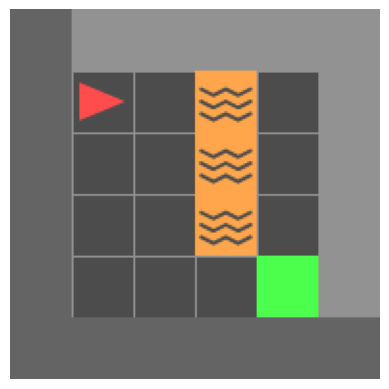


STEP 2

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal

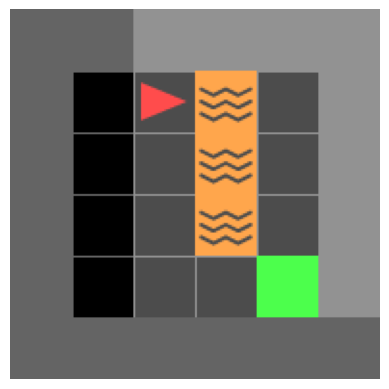


STEP 3

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4

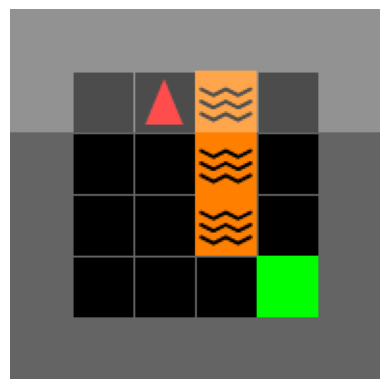


STEP 4

OBSERVATION:
 Agent at [2,1] facing left. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing left. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], w

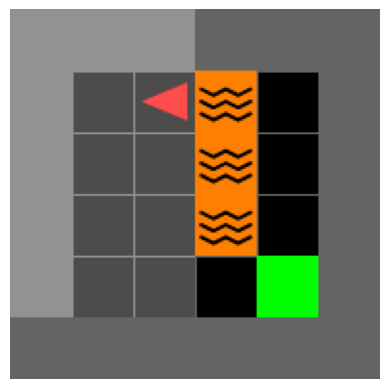


STEP 5

OBSERVATION:
 Agent at [2,1] facing down. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing down. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], w

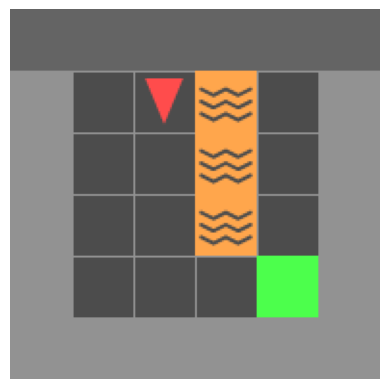


STEP 6

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal

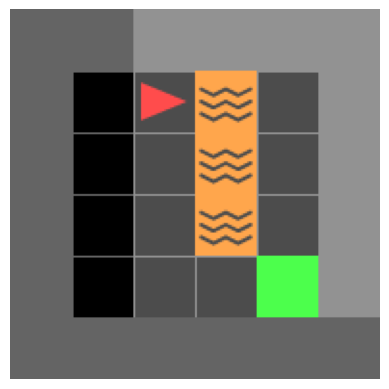


STEP 7

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4

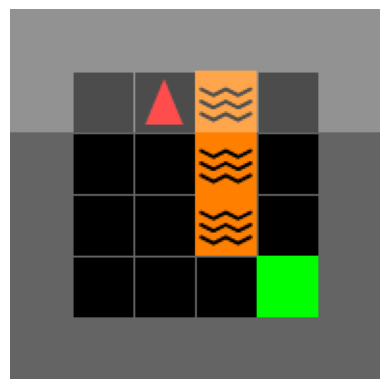


STEP 8

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4

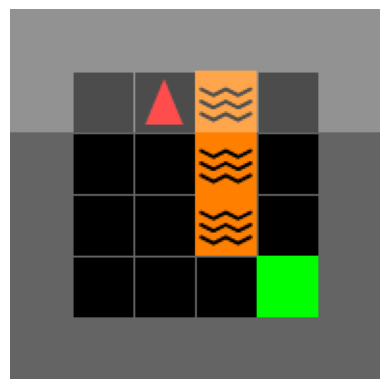


STEP 9

OBSERVATION:
 Agent at [2,1] facing left. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing left. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], w

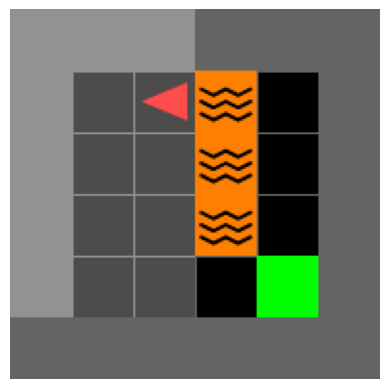


STEP 10

OBSERVATION:
 Agent at [2,1] facing down. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing down. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], 

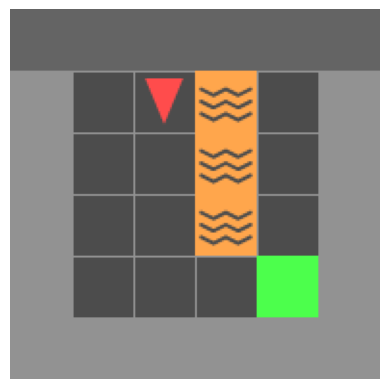


STEP 11

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goa

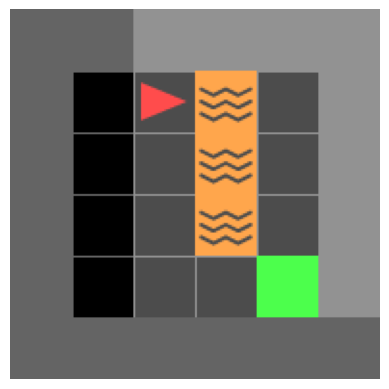


STEP 12

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [

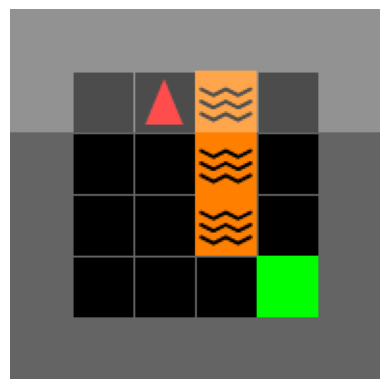


STEP 13

OBSERVATION:
 Agent at [2,1] facing left. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing left. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], 

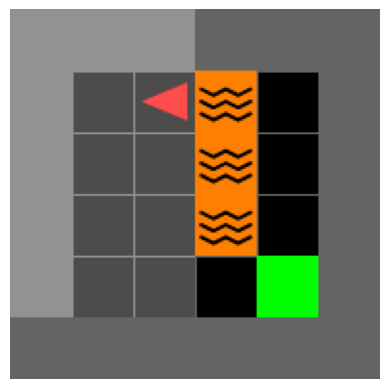


STEP 14

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [

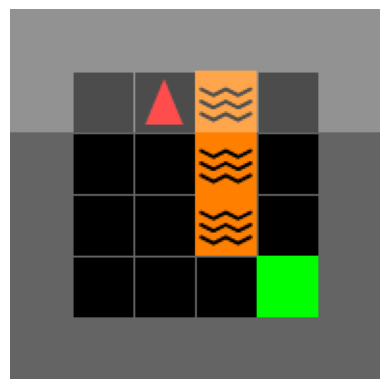


STEP 15

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goa

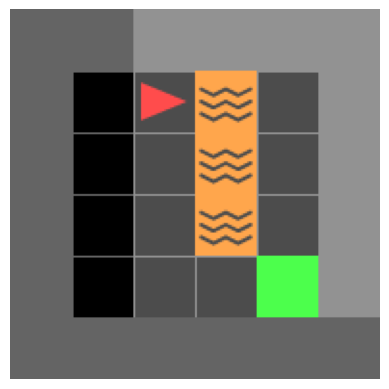

In [ ]:
debug_agent(agent, steps=15)


STEP 1

OBSERVATION:
 Agent at [1,1] facing right. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:
 

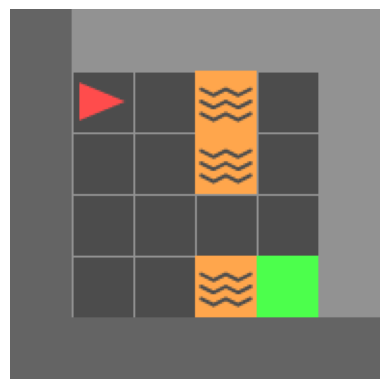


STEP 2

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important ru

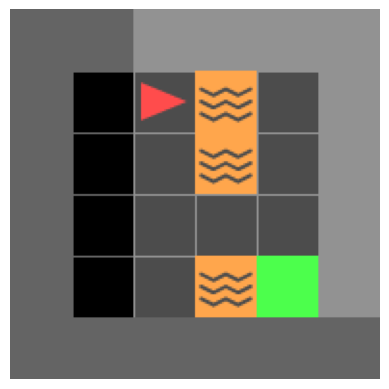


STEP 3

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:

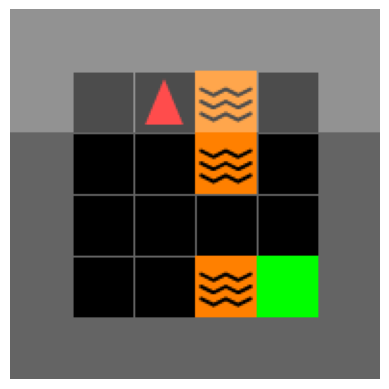


STEP 4

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important ru

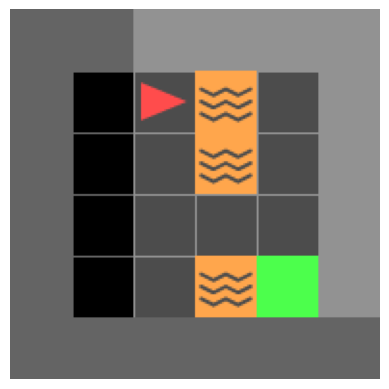


STEP 5

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:

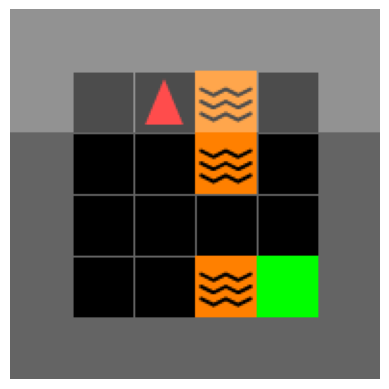

In [ ]:
debug_agent(agent, steps=5)


STEP 1

OBSERVATION:
 Agent at [1,1] facing right. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:
 

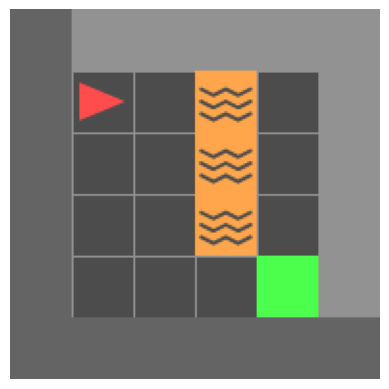


STEP 2

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important ru

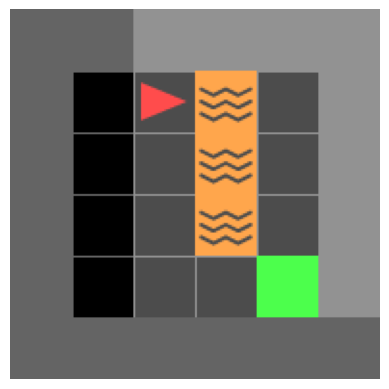


STEP 3

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:

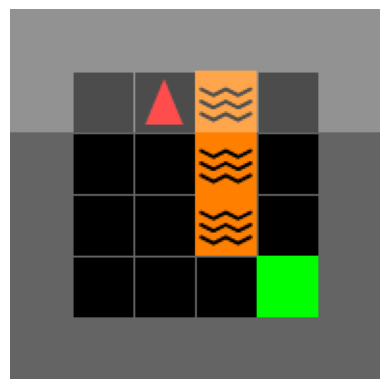


STEP 4

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important ru

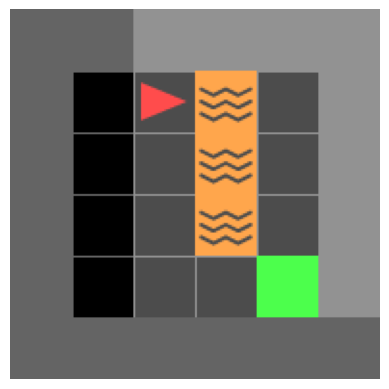


STEP 5

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:

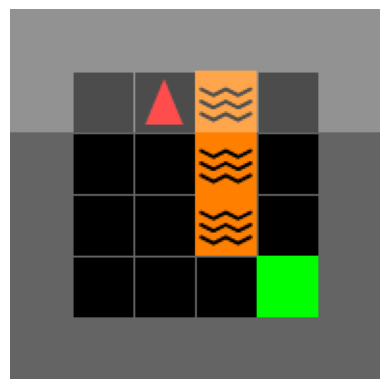


STEP 6

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important ru

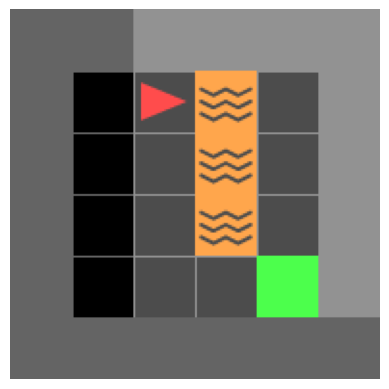


STEP 7

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:

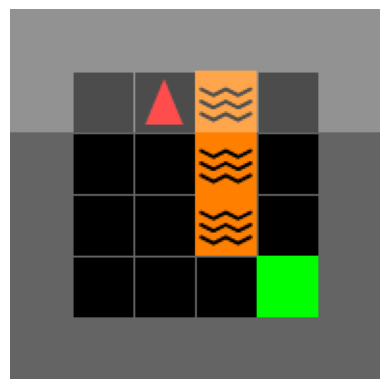


STEP 8

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important ru

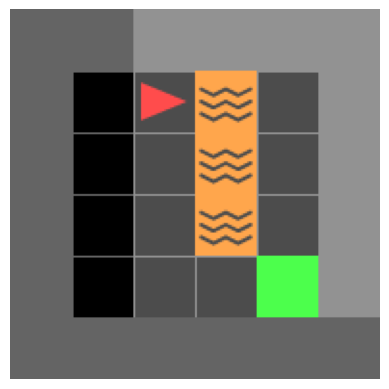


STEP 9

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule:

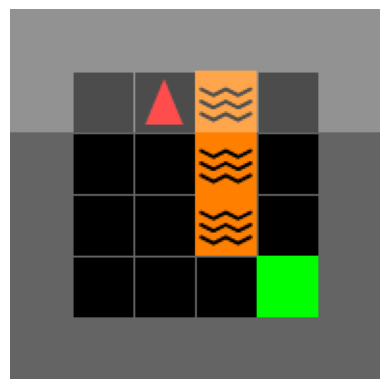


STEP 10

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important r

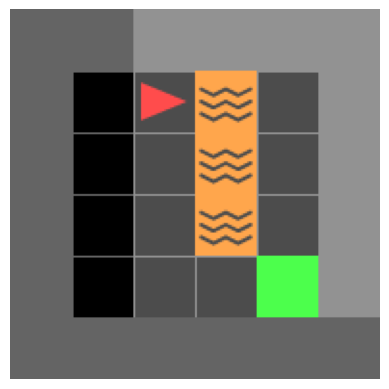


STEP 11

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule

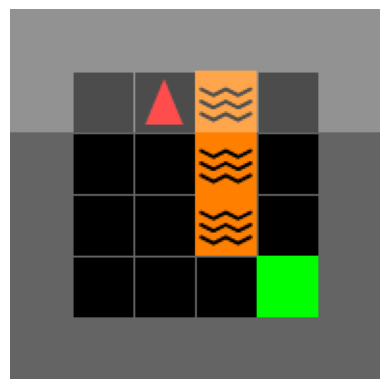


STEP 12

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important r

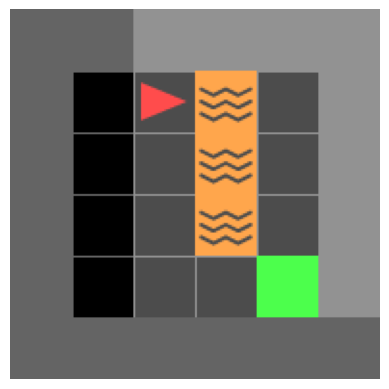


STEP 13

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule

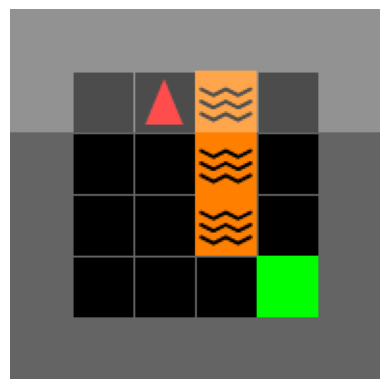


STEP 14

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important r

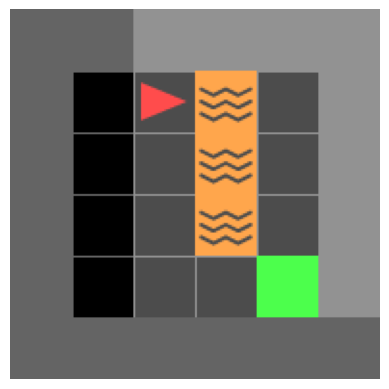


STEP 15

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,3], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal tile while avoiding lava
    3. If there is no lava in front, choose the path that is closest to the goal tile
    4. Use the previous reasoningto understand which actions have laready been taken, but make decision based primarily on the current situation.

    Important rule

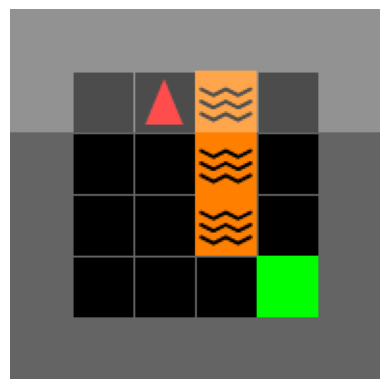

In [ ]:
debug_agent(agent, steps=15)


STEP 1

OBSERVATION:
 Agent at [1,1] facing right. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal t

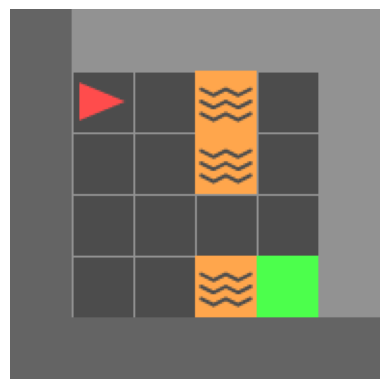


STEP 2

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal

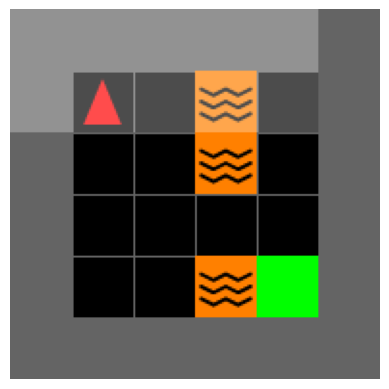


STEP 3

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the go

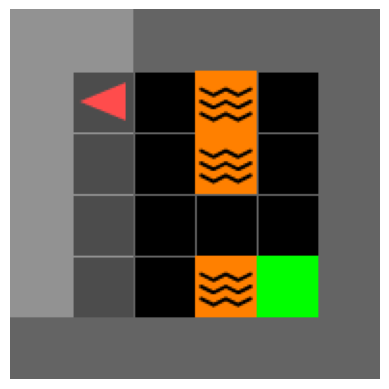


STEP 4

OBSERVATION:
 Agent at [1,1] facing down. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal ti

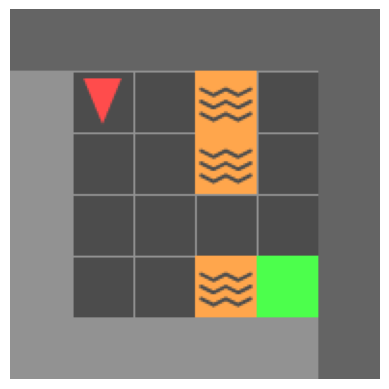


STEP 5

OBSERVATION:
 Agent at [1,1] facing right. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal t

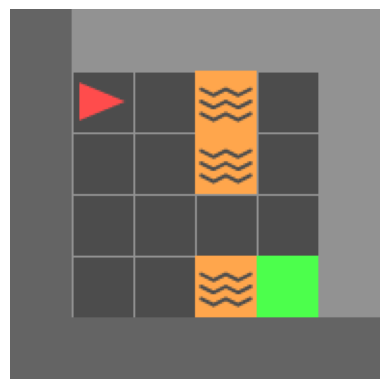


STEP 6

OBSERVATION:
 Agent at [2,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the g

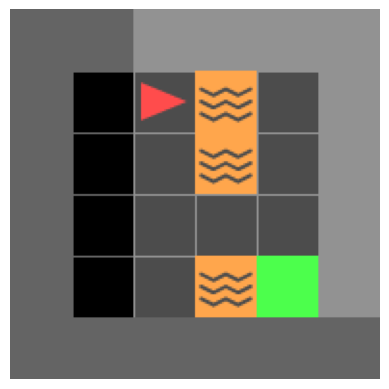


STEP 7

OBSERVATION:
 Agent at [2,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal

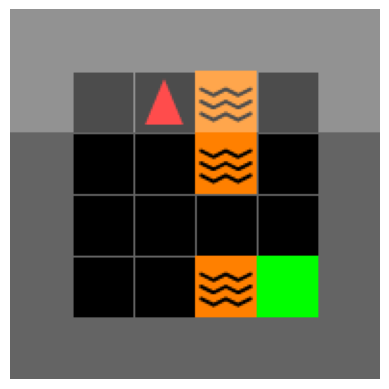


STEP 8

OBSERVATION:
 Agent at [2,1] facing left. The cell directly in front of you is empty. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goal ti

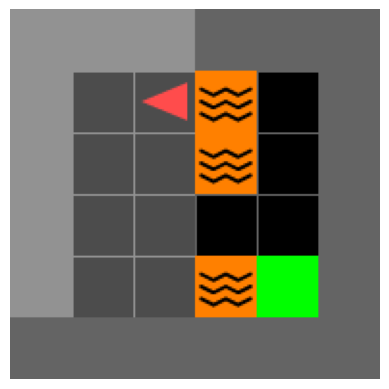


STEP 9

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the go

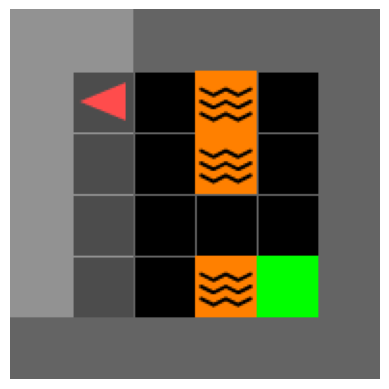


STEP 10

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the g

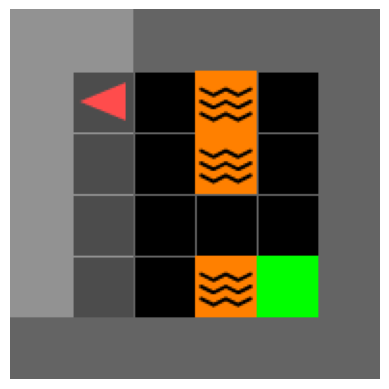


STEP 11

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the g

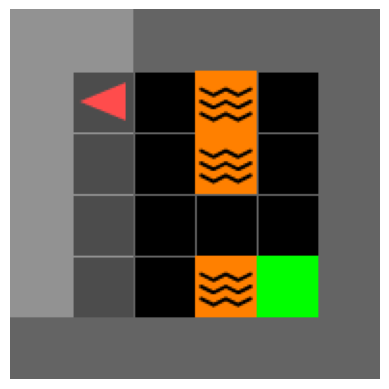


STEP 12

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the g

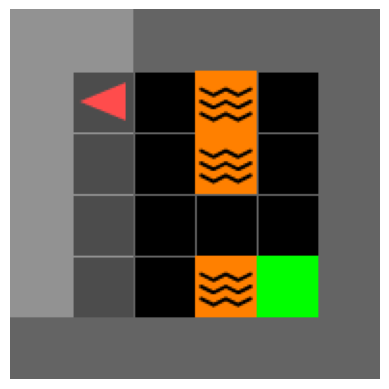


STEP 13

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the goa

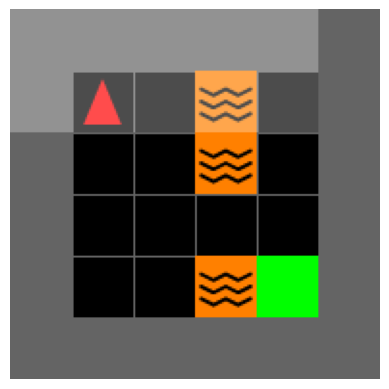


STEP 14

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the g

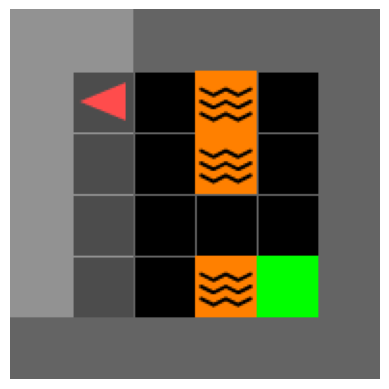


STEP 15

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], wall at [2,5], wall at [3,0], lava at [3,1], lava at [3,2], lava at [3,4], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.

    Guidelines:
    1. Coordinates are in representations of (columns, rows)
    2. If there is lava in front, choose the path that is closest to the g

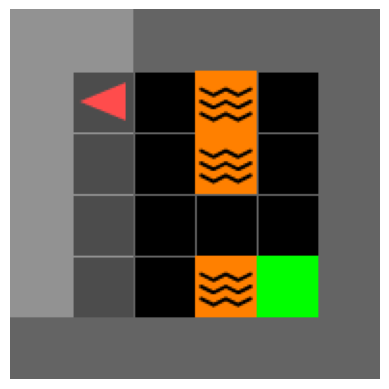

In [ ]:
debug_agent(agent, steps=15)


STEP 1

OBSERVATION:
 Agent at [1,1] facing right. The cell directly in front of you contains lava. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, ch

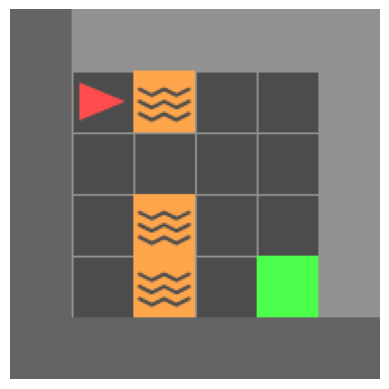


STEP 2

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, choos

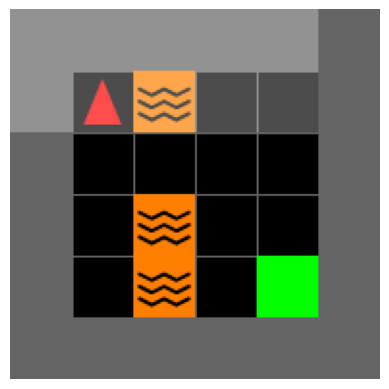


STEP 3

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, cho

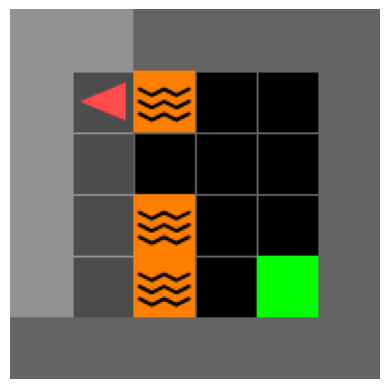


STEP 4

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, choos

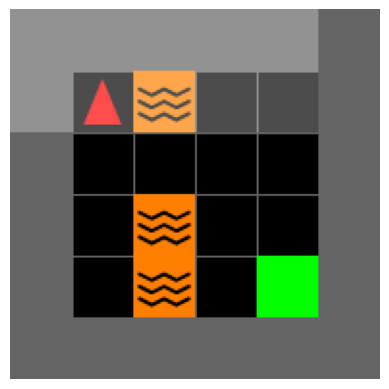


STEP 5

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, cho

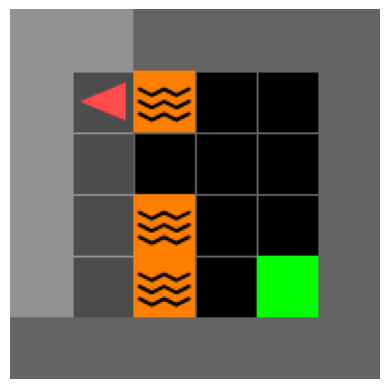


STEP 6

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, choos

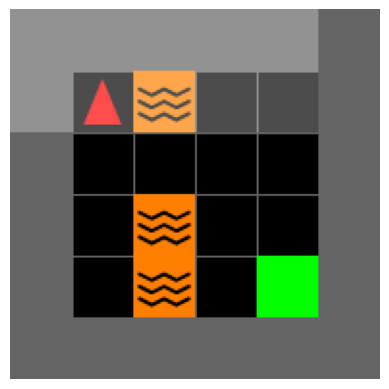


STEP 7

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, cho

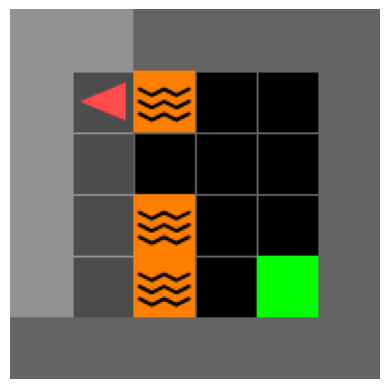


STEP 8

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, choos

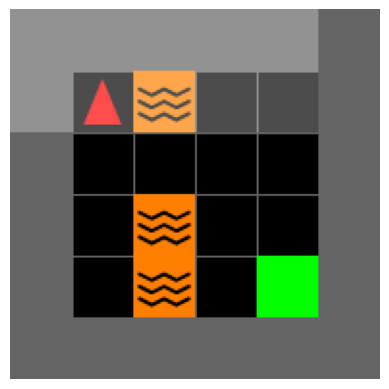


STEP 9

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, cho

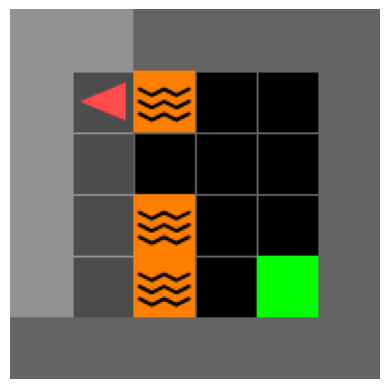


STEP 10

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, choo

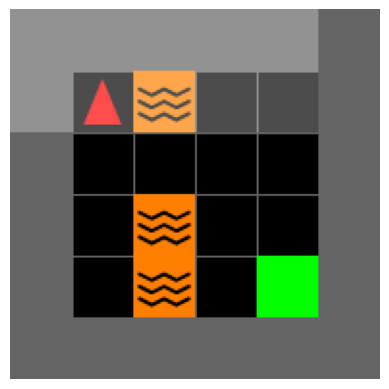


STEP 11

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, ch

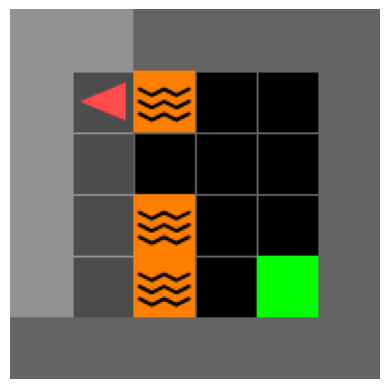


STEP 12

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, choo

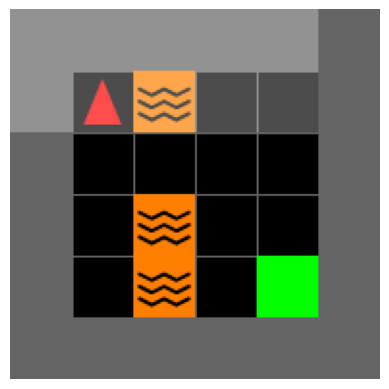


STEP 13

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, ch

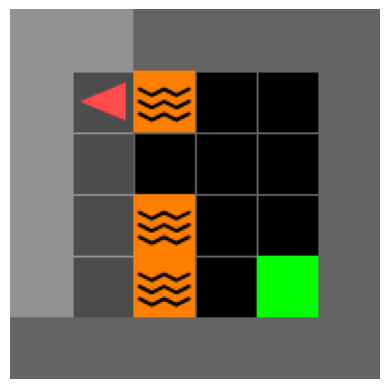


STEP 14

OBSERVATION:
 Agent at [1,1] facing up. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, choo

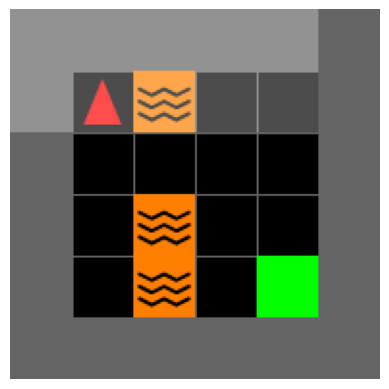


STEP 15

OBSERVATION:
 Agent at [1,1] facing left. The cell directly in front of you contains wall. Objects: wall at [0,0], wall at [0,1], wall at [0,2], wall at [0,3], wall at [0,4], wall at [0,5], wall at [1,0], wall at [1,5], wall at [2,0], lava at [2,1], lava at [2,3], lava at [2,4], wall at [2,5], wall at [3,0], wall at [3,5], wall at [4,0], goal at [4,4], wall at [4,5], wall at [5,0], wall at [5,1], wall at [5,2], wall at [5,3], wall at [5,4], wall at [5,5].

PROMPT:
 
    You are an intelligent agent navigating a grid world.

    Your goal is to reach the GREEN GOAL tile while avoiding lava.

    Available actions:
    turn_left, turn_right, move_forward

    Environment rules:

    Turning rotates in place.

    move_forward moves one tile in the direction you face.

    You cannot move through walls.

    Stepping on lava ends the episode.

    Behavior rules:

    Do not oscillate between turn_left and turn_right.

    If your previous action did not change the situation, ch

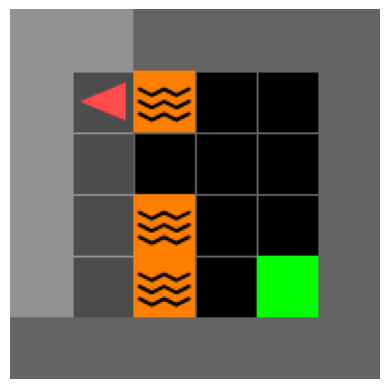

In [ ]:
debug_agent(agent, steps=15)

My prompt with Calvin's text wrapper


STEP 1

OBSERVATION:
 - Step 0 of 100.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 0 of 100.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1

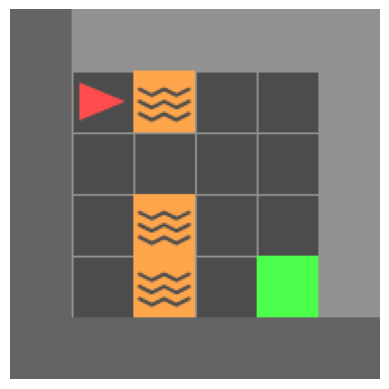


STEP 2

OBSERVATION:
 - Step 1 of 100.
- Your last actions: turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 1 of 100.
- Your last actions: turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps

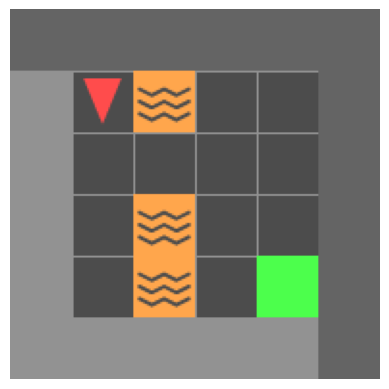


STEP 3

OBSERVATION:
 - Step 2 of 100.
- Your last actions: turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 2 of 100.
- Your last actions: turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your

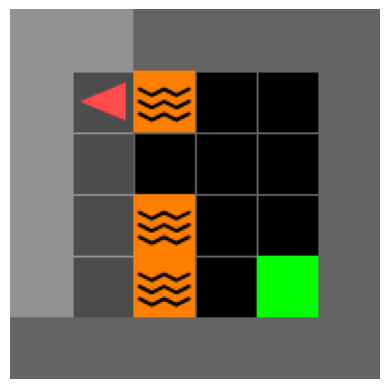


STEP 4

OBSERVATION:
 - Step 3 of 100.
- Your last actions: turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 3 of 100.
- Your last actions: turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps for

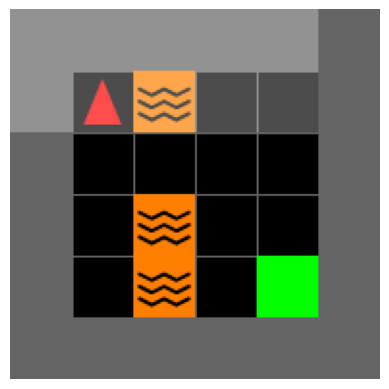


STEP 5

OBSERVATION:
 - Step 4 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 4 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wal

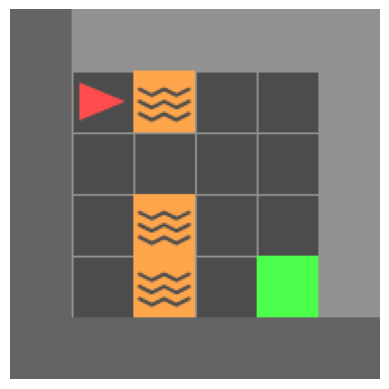


STEP 6

OBSERVATION:
 - Step 5 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 5 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are

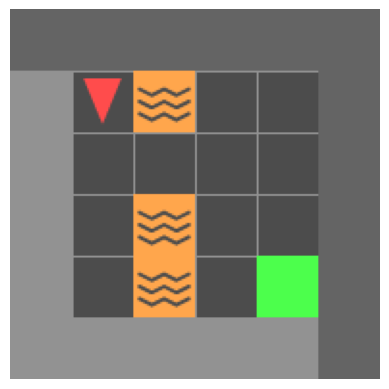


STEP 7

OBSERVATION:
 - Step 6 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 6 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are

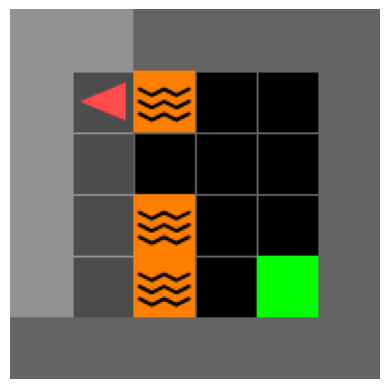


STEP 8

OBSERVATION:
 - Step 7 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 7 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are

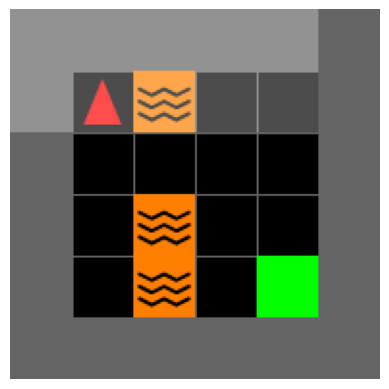


STEP 9

OBSERVATION:
 - Step 8 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 8 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are

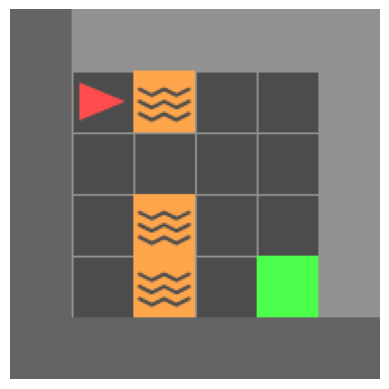


STEP 10

OBSERVATION:
 - Step 9 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 9 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You ar

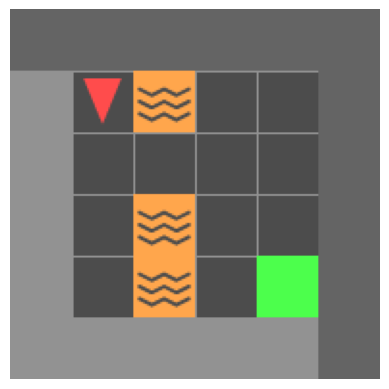


STEP 11

OBSERVATION:
 - Step 10 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 10 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You 

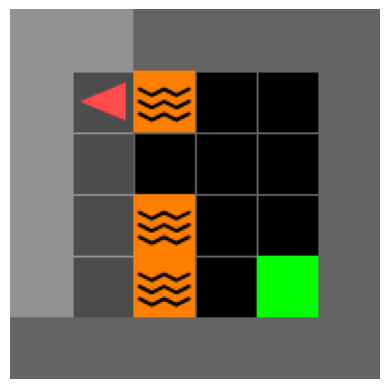


STEP 12

OBSERVATION:
 - Step 11 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 11 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You 

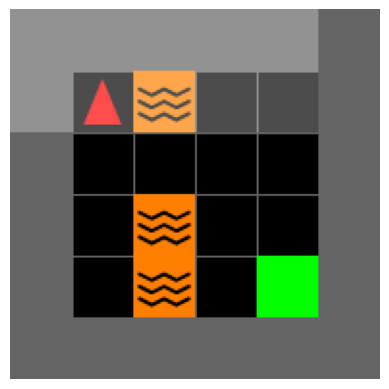


STEP 13

OBSERVATION:
 - Step 12 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 12 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You 

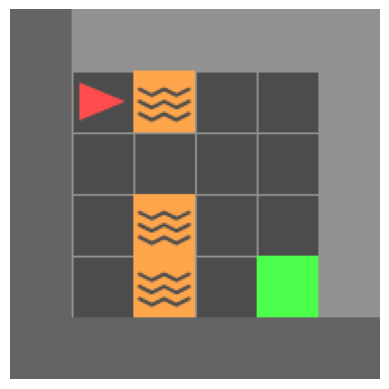


STEP 14

OBSERVATION:
 - Step 13 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 13 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You 

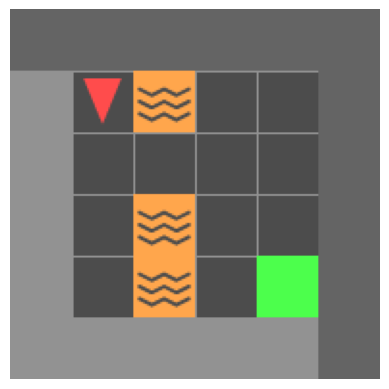


STEP 15

OBSERVATION:
 - Step 14 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You are right in front of a wall.
- LAVA at 4 steps forward and 1 steps to your left.
- LAVA at 2 steps forward and 1 steps to your left.
- LAVA at 1 steps forward and 1 steps to your left.
- You see the GREEN GOAL located 1 steps forward and 1 steps to your right.

PROMPT:
 
    You are navigating a grid world.

    Goal: reach the goal tile while avoiding lava by reasoning step-by-step.

    Reasoning procedure:
    1. Identify lava tile positions.
    2. Determine if lava forms a barrier between the agent and the goal.
    3. Identify the safe gap in the barrier.
    4. Move to align with the gap before crossing.
    5. Never move forward into lava or walls.


    Important rule:
    Never move_forward if the front cell contains lava.

    Observation:
    - Step 14 of 100.
- Your last actions: turn_right, turn_right, turn_right, turn_right, turn_right.
- You 

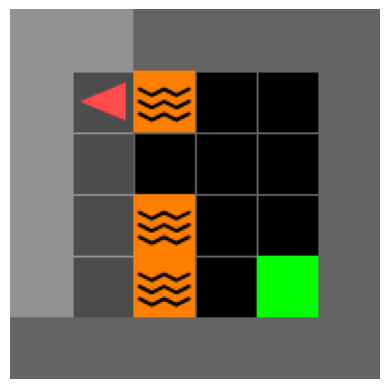

In [ ]:
debug_agent(agent, steps=15)

In [ ]:
evaluate_agent(agent,
                   env_name="MiniGrid-LavaGapS6-v0",
                   num_episodes=10,
                   max_steps_per_episode=50)

Evaluating MiniGrid-LavaGapS6-v0 for 10 episodes
Episode 1/10 | Success: False | Steps: 50
Episode 2/10 | Success: False | Steps: 50
Episode 3/10 | Success: False | Steps: 50
Episode 4/10 | Success: False | Steps: 50
Episode 5/10 | Success: False | Steps: 50
Episode 6/10 | Success: False | Steps: 50
Episode 7/10 | Success: False | Steps: 50
Episode 8/10 | Success: False | Steps: 50
Episode 9/10 | Success: False | Steps: 50
Episode 10/10 | Success: False | Steps: 50

🏆 Final Metrics
Success Rate: 0.00%
Avg Steps (successful episodes): inf
Avg Inference Time per step: 5.0847 sec


{'success_count': 0,
 'total_steps_success': 0,
 'total_inference_time': 2542.3669679164886,
 'total_tokens': 0,
 'total_actions': 500}

In [ ]:
evaluate_agent(agent,
                   env_name="MiniGrid-LavaGapS6-v0",
                   num_episodes=10,
                   max_steps_per_episode=50)

Evaluating MiniGrid-LavaGapS6-v0 for 10 episodes
Episode 1/10 | Success: False | Steps: 50
Episode 2/10 | Success: False | Steps: 50
Episode 3/10 | Success: False | Steps: 50
Episode 4/10 | Success: False | Steps: 50
Episode 5/10 | Success: False | Steps: 50
Episode 6/10 | Success: False | Steps: 50
Episode 7/10 | Success: False | Steps: 50
Episode 8/10 | Success: False | Steps: 50
Episode 9/10 | Success: False | Steps: 50
Episode 10/10 | Success: False | Steps: 50

🏆 Final Metrics
Success Rate: 0.00%
Avg Steps (successful episodes): inf
Avg Inference Time per step: 4.2779 sec


{'success_count': 0,
 'total_steps_success': 0,
 'total_inference_time': 2138.9654507637024,
 'total_tokens': 0,
 'total_actions': 500}

In [ ]:
evaluate_agent(agent,
                   env_name="MiniGrid-LavaGapS6-v0",
                   num_episodes=10,
                   max_steps_per_episode=100)

Evaluating MiniGrid-LavaGapS6-v0 for 10 episodes
Episode 1/10 | Success: False | Steps: 100 | GIF saved: episode_gifs/episode_1.gif
Episode 2/10 | Success: False | Steps: 100 | GIF saved: episode_gifs/episode_2.gif
Episode 3/10 | Success: False | Steps: 100 | GIF saved: episode_gifs/episode_3.gif



KeyboardInterrupt

